In [ ]:
 # Problem Statement -> https://drive.google.com/file/d/1JraPenCa5CZ_6UucYCsHDbxDqc00sAf7/view

In [ ]:
# Dataset Link -> https://drive.google.com/file/d/1stLh4iwPS_szCE_bkt4w2Vy6UCybKO0q/view

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/Covid_19_Clean_Complete (2) (1).csv')

In [ ]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
#Rename columns
df.rename(columns={"Province/State" : "State" , "Country/Region" : "Country"}, inplace=True)

EDA

In [ ]:
#Cheaking NULl value
df.isnull().sum()

,0
State,34404
Country,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [ ]:
#filling null with mode
df['State'] = df['State'].fillna(df['State'].mode()[0])

In [ ]:
#cheaking duplicated
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape


(49068, 10)

In [ ]:
#cheaking confirm case
confirmed_cases = df.groupby(["Date"])["Confirmed"].sum().reset_index()
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


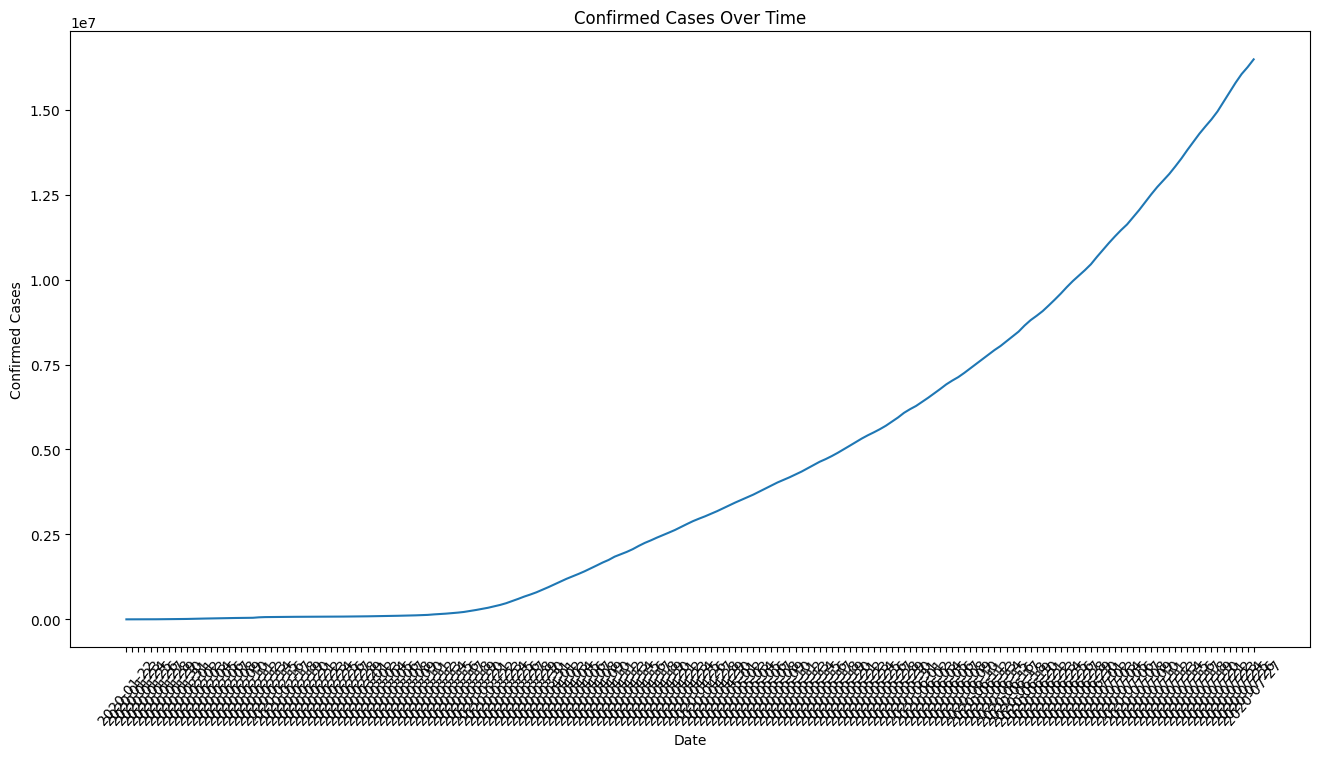

In [ ]:
#visualization of confirm case with time
plt.figure(figsize=(16,8))
plt.plot(confirmed_cases["Date"], confirmed_cases["Confirmed"])
plt.title("Confirmed Cases Over Time")
plt.xticks(rotation=50)
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

In [ ]:
#cheaking Death case
death_cases = df.groupby(["Date"])["Deaths"].sum().reset_index()
death_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


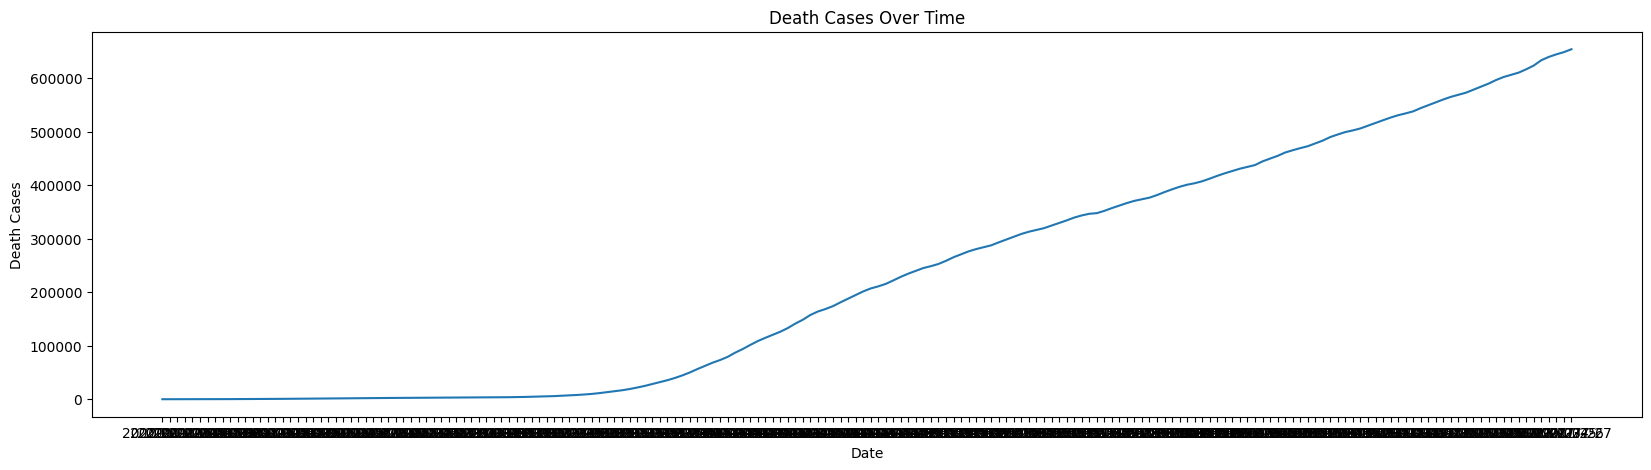

In [ ]:
#visualization of Death case with time
plt.figure(figsize=(20,5))
plt.xlabel("Date")
plt.title("Death Cases Over Time")
plt.ylabel("Death Cases")
sns.lineplot(data=death_cases, x="Date", y="Deaths")
plt.show()

finding the most affected countries

In [ ]:
df.columns

Index(['State', 'Country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [ ]:
#groping data as per country
data_country = df.groupby(df['Country'])[[ 'Confirmed', 'Active', 'Deaths','Recovered']].sum().reset_index()
data_country

,Country,Confirmed,Active,Deaths,Recovered
0,Afghanistan,1936390,1089052,49098,798240
1,Albania,196702,72117,5708,118877
2,Algeria,1179755,345886,77972,755897
3,Andorra,94404,19907,5423,69074
4,Angola,22662,15011,1078,6573
...,...,...,...,...,...
182,West Bank and Gaza,233461,170967,1370,61124
183,Western Sahara,901,190,63,648
184,Yemen,67180,25694,17707,23779
185,Zambia,129421,43167,2643,83611


Analysing Top 3 country data


In [ ]:
# Top 3 countries based on confiremed cases ->
top3_confirmed = data_country.sort_values(by="Confirmed", ascending=False).head(3)

In [ ]:
top3_confirmed

,Country,Confirmed,Active,Deaths,Recovered
173,US,224345948,156981121,11011411,56353416
23,Brazil,89524967,31094060,3938034,54492873
138,Russia,45408411,19668578,619385,25120448


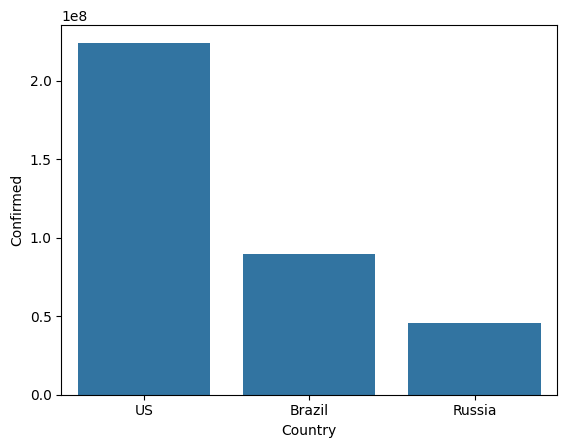

In [ ]:
#visualization of country confirm case
sns.barplot(data=top3_confirmed, x="Country", y="Confirmed")
plt.show()

In [ ]:
# Top 3 countries based on death cases ->
top3_deaths = data_country.sort_values(by="Deaths", ascending=False).head(3)

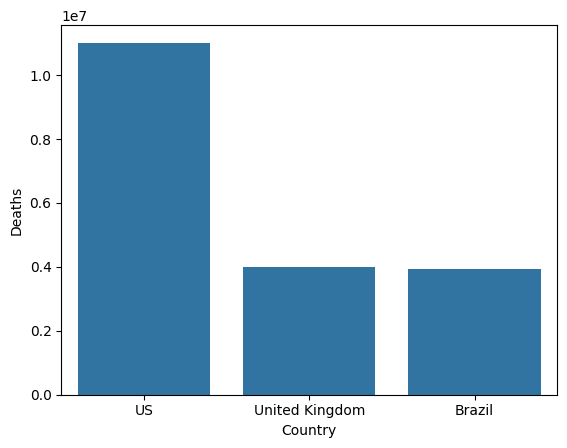

In [ ]:
#visualization death by country
sns.barplot(data=top3_deaths, x="Country", y="Deaths")
plt.show()

In [ ]:
#top 3 recoverd country
top3_recovered = data_country.sort_values(by="Recovered", ascending=False).head(3)

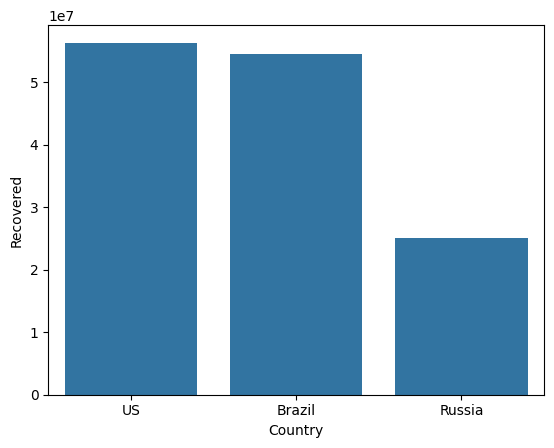

In [ ]:
#visualization Recoverd by country
sns.barplot(data=top3_recovered, x="Country", y="Recovered")
plt.show()


Dividing all top 3 by country

In [ ]:
US = df[df["Country"] == "US"]
BZ = df[df['Country'] == "Brazil"]
RU = df[df["Country"] == "Russia"]

In [ ]:
data_RU = RU.groupby("Date")[["Confirmed", "Deaths", "Active", "Recovered"]].sum().reset_index()
data_RU

,Date,Confirmed,Deaths,Active,Recovered
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,793720,12873,201552,579295
184,2020-07-24,799499,13026,198745,587728
185,2020-07-25,805332,13172,196096,596064
186,2020-07-26,811073,13249,198652,599172


In [ ]:
data_BZ = BZ.groupby("Date")[["Confirmed", "Deaths", "Active", "Recovered"]].sum().reset_index()
data_BZ

,Date,Confirmed,Deaths,Active,Recovered
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,2287475,84082,583080,1620313
184,2020-07-24,2343366,85238,564914,1693214
185,2020-07-25,2394513,86449,522705,1785359
186,2020-07-26,2419091,87004,519174,1812913


In [ ]:
data_US = US.groupby("Date")[["Confirmed", "Deaths", "Active", "Recovered"]].sum().reset_index()
data_US

,Date,Confirmed,Deaths,Active,Recovered
0,2020-01-22,1,0,1,0
1,2020-01-23,1,0,1,0
2,2020-01-24,2,0,2,0
3,2020-01-25,2,0,2,0
4,2020-01-26,5,0,5,0
...,...,...,...,...,...
183,2020-07-23,4038816,144430,2661117,1233269
184,2020-07-24,4112531,145560,2705347,1261624
185,2020-07-25,4178970,146465,2753091,1279414
186,2020-07-26,4233923,146935,2789125,1297863


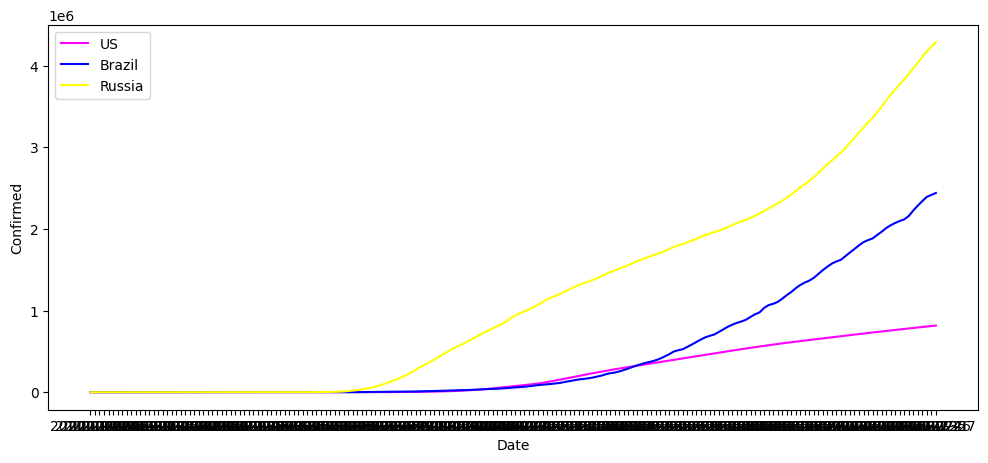

In [ ]:
# visualization of top 3 contry confirmed cases
plt.figure(figsize=(12,5))
sns.lineplot(data=data_RU, x="Date", y="Confirmed", color="magenta", label="US")
sns.lineplot(data=data_BZ, x="Date", y="Confirmed", color="blue", label="Brazil")
sns.lineplot(data=data_US, x="Date", y="Confirmed", color="yellow", label="Russia")
plt.show()

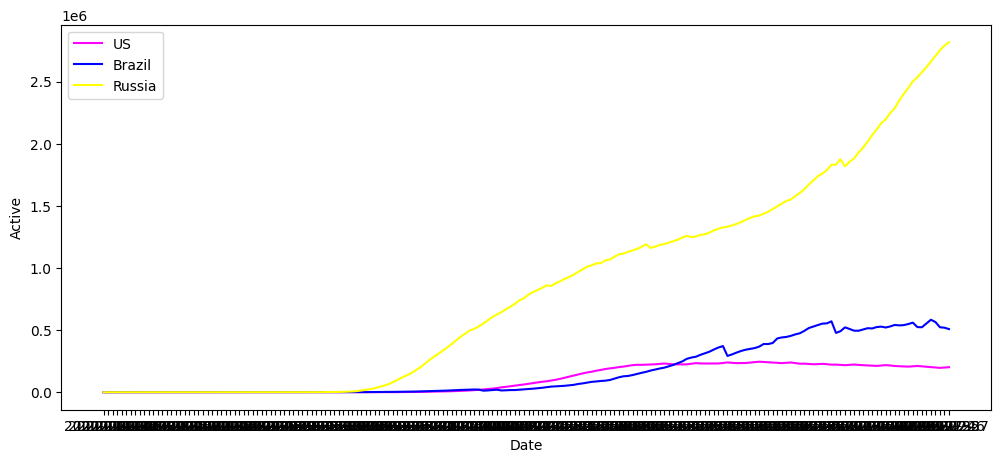

In [ ]:
# visualization of top 3 contry Active cases
plt.figure(figsize=(12,5))
sns.lineplot(data=data_RU, x="Date", y="Active", color="magenta", label="US")
sns.lineplot(data=data_BZ, x="Date", y="Active", color="blue", label="Brazil")
sns.lineplot(data=data_US, x="Date", y="Active", color="yellow", label="Russia")
plt.show()

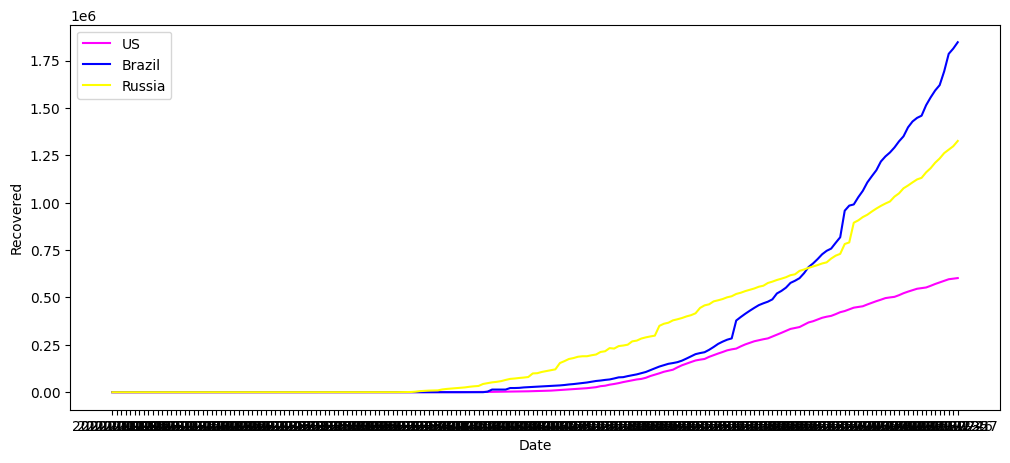

In [ ]:
# visualization of top 3 contry Recovered cases
plt.figure(figsize=(12,5))
sns.lineplot(data=data_RU, x="Date", y="Recovered", color="magenta", label="US")
sns.lineplot(data=data_BZ, x="Date", y="Recovered", color="blue", label="Brazil")
sns.lineplot(data=data_US, x="Date", y="Recovered", color="yellow", label="Russia")
plt.show()

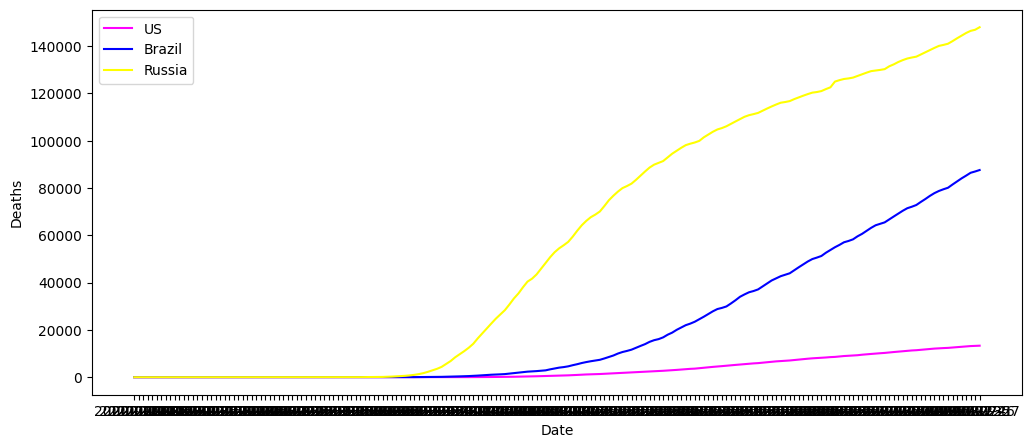

In [ ]:
# visualization of top 3 contry Deaths cases
plt.figure(figsize=(12,5))
sns.lineplot(data=data_RU, x="Date", y="Deaths", color="magenta", label="US")
sns.lineplot(data=data_BZ, x="Date", y="Deaths", color="blue", label="Brazil")
sns.lineplot(data=data_US, x="Date", y="Deaths", color="yellow", label="Russia")
plt.show()

Forcasting of future 7 days Confirm cases

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:
confirmed_cases = df.groupby(["Date"])["Confirmed"].sum().reset_index()



In [ ]:
con_prophet_data = confirmed_cases.rename(columns={"Date" : "ds", "Confirmed" : "y"})



In [ ]:
model= Prophet()

In [ ]:
model.fit(con_prophet_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=7)       # For future 7 days
future

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [ ]:
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.304446e+05,7.860333e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.128970e+05,9.734121e+04,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-9.475104e+04,1.137048e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-1.006159e+05,1.092387e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-9.851514e+04,1.139568e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.663379e+07,1.684632e+07,1.673928e+07,1.675037e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.685238e+07,1.706783e+07,1.693639e+07,1.695919e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705258e+07,1.727491e+07,1.713366e+07,1.717068e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725757e+07,1.747581e+07,1.732989e+07,1.738309e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [ ]:
forecast[["yhat_lower", "yhat_upper", "yhat"]]

,yhat_lower,yhat_upper,yhat
0,-1.304446e+05,7.860333e+04,-2.067685e+04
1,-1.128970e+05,9.734121e+04,-8.050953e+03
2,-9.475104e+04,1.137048e+05,5.827449e+03
3,-1.006159e+05,1.092387e+05,1.217668e+04
4,-9.851514e+04,1.139568e+05,8.405020e+03
...,...,...,...
190,1.663379e+07,1.684632e+07,1.674392e+07
191,1.685238e+07,1.706783e+07,1.695911e+07
192,1.705258e+07,1.727491e+07,1.716677e+07
193,1.725757e+07,1.747581e+07,1.736430e+07


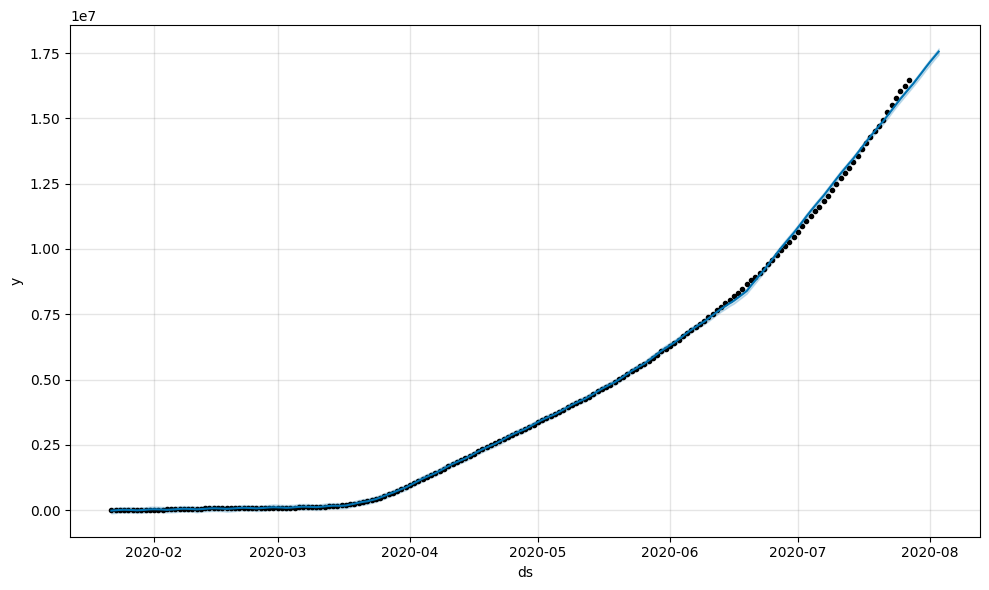

In [ ]:
model.plot(forecast)
plt.show()

Forcasting of future 7 days Deaths cases

In [ ]:
!pip install prophet


In [ ]:
death_cases = df.groupby(["Date"])["Deaths"].sum().reset_index()

In [ ]:
dea_prophet_data = death_cases.rename(columns={"Date" : "ds", "Deaths" : "y"})

In [ ]:
model=Prophet()

In [ ]:
model.fit(dea_prophet_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=7)       # For future 7 days
future

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [ ]:
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-522.113185,-2619.059262,1121.942705,-522.113185,-522.113185,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,0.0,0.0,0.0,-713.300939
1,2020-01-23,-432.419342,-1964.232190,1681.352990,-432.419342,-432.419342,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,-43.747277
2,2020-01-24,-342.725499,-1438.013252,2525.289781,-342.725499,-342.725499,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,531.538580
3,2020-01-25,-253.031656,-1591.584887,2442.673264,-253.031656,-253.031656,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,473.857809
4,2020-01-26,-163.337813,-2313.589894,1631.648810,-163.337813,-163.337813,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,-328.938272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,663102.734264,661416.744663,665648.331401,662920.241391,663464.165131,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,663491.406328
191,2020-07-31,668132.143204,666786.470769,671151.623004,667731.563774,668880.003582,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,669006.407283
192,2020-08-01,673161.552144,671530.489719,676396.690349,672343.931314,674294.538257,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,673888.441609
193,2020-08-02,678190.961084,675699.530081,680576.739242,676839.706503,679780.971095,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,678025.360624


In [ ]:
forecast[["yhat_lower", "yhat_upper", "yhat"]]

,yhat_lower,yhat_upper,yhat
0,-2619.059262,1121.942705,-713.300939
1,-1964.232190,1681.352990,-43.747277
2,-1438.013252,2525.289781,531.538580
3,-1591.584887,2442.673264,473.857809
4,-2313.589894,1631.648810,-328.938272
...,...,...,...
190,661416.744663,665648.331401,663491.406328
191,666786.470769,671151.623004,669006.407283
192,671530.489719,676396.690349,673888.441609
193,675699.530081,680576.739242,678025.360624


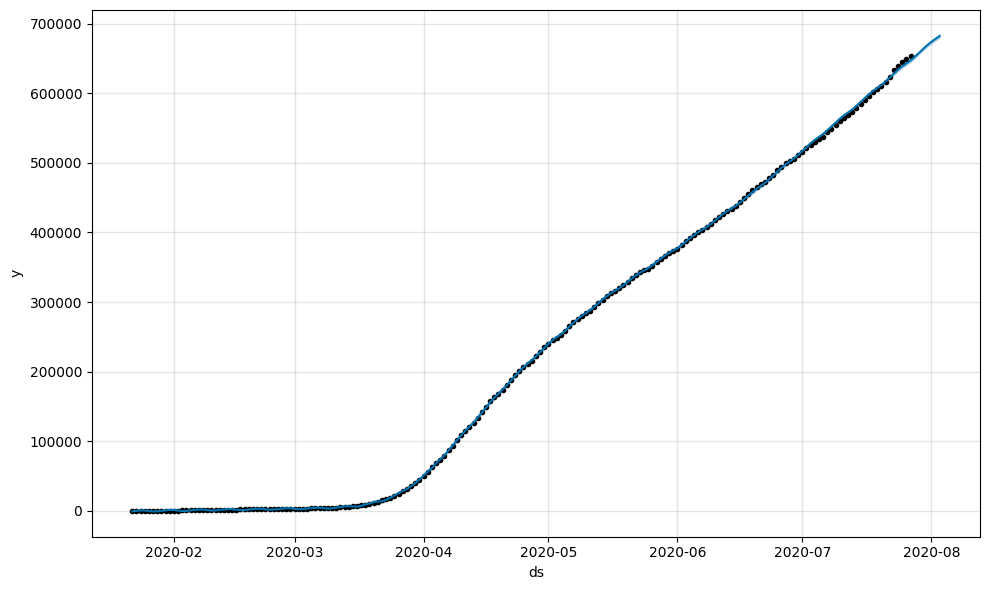

In [ ]:
model.plot(forecast)
plt.show()

Forcasting of future 7 days Recoverd  cases

In [ ]:
!pip install prophet


In [ ]:
from prophet import Prophet


In [ ]:
recoverd_cases = df.groupby(["Date"])['Recovered'].sum().reset_index()


In [ ]:
rec_prophet_data = recoverd_cases.rename(columns={"Date" : "ds", "Recovered" : "y"})


In [ ]:
model = Prophet()


In [ ]:
model.fit(rec_prophet_data)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=7)       # For future 7 days
future


,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [ ]:
forecast = model.predict(future)
forecast


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1.360144e+04,-9.436309e+04,6.118158e+04,-1.360144e+04,-1.360144e+04,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,0.0,0.0,0.0,-1.844208e+04
1,2020-01-23,-1.243662e+04,-9.570471e+04,6.414389e+04,-1.243662e+04,-1.243662e+04,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,-1.118182e+04
2,2020-01-24,-1.127180e+04,-7.967176e+04,7.143169e+04,-1.127180e+04,-1.127180e+04,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,-5.175647e+03
3,2020-01-25,-1.010697e+04,-7.746625e+04,8.211481e+04,-1.010697e+04,-1.010697e+04,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,-4.075311e+02
4,2020-01-26,-8.942151e+03,-8.926657e+04,7.212011e+04,-8.942151e+03,-8.942151e+03,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,-9.825630e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,9.594538e+06,9.516830e+06,9.674168e+06,9.591209e+06,9.599718e+06,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,9.595793e+06
191,2020-07-31,9.731096e+06,9.658301e+06,9.823737e+06,9.724388e+06,9.740361e+06,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,9.737193e+06
192,2020-08-01,9.867654e+06,9.797624e+06,9.963315e+06,9.855782e+06,9.882247e+06,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,9.877354e+06
193,2020-08-02,1.000421e+07,9.923593e+06,1.009222e+07,9.986789e+06,1.002535e+07,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,1.000333e+07


In [ ]:
forecast[["yhat_lower", "yhat_upper", "yhat"]]


,yhat_lower,yhat_upper,yhat
0,-9.436309e+04,6.118158e+04,-1.844208e+04
1,-9.570471e+04,6.414389e+04,-1.118182e+04
2,-7.967176e+04,7.143169e+04,-5.175647e+03
3,-7.746625e+04,8.211481e+04,-4.075311e+02
4,-8.926657e+04,7.212011e+04,-9.825630e+03
...,...,...,...
190,9.516830e+06,9.674168e+06,9.595793e+06
191,9.658301e+06,9.823737e+06,9.737193e+06
192,9.797624e+06,9.963315e+06,9.877354e+06
193,9.923593e+06,1.009222e+07,1.000333e+07


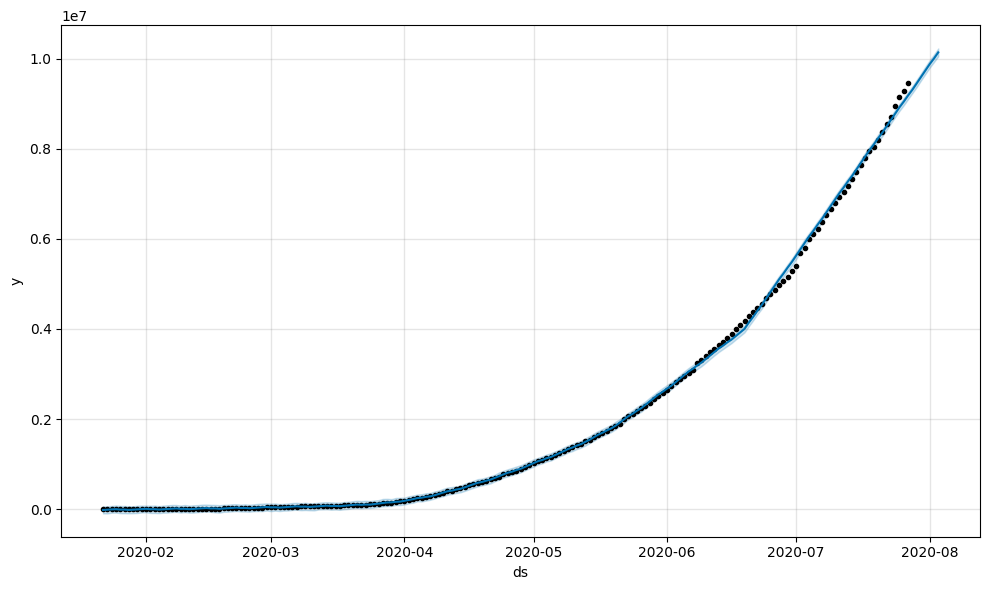

In [ ]:
model.plot(forecast)
plt.show()

Forcasting of future 7 days Active cases

In [ ]:

!pip install prophet


In [ ]:
from prophet import Prophet

In [ ]:
active_cases_cases = df.groupby(["Date"])['Recovered'].sum().reset_index()

In [ ]:
act_prophet_data = active_cases_cases.rename(columns={"Date" : "ds", "Recovered" : "y"})


In [ ]:
model=Prophet()

In [ ]:
model.fit(act_prophet_data)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=7)       # For future 7 days
future

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [ ]:
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1.360144e+04,-9.619917e+04,5.714047e+04,-1.360144e+04,-1.360144e+04,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,0.0,0.0,0.0,-1.844208e+04
1,2020-01-23,-1.243662e+04,-8.680679e+04,6.870329e+04,-1.243662e+04,-1.243662e+04,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,-1.118182e+04
2,2020-01-24,-1.127180e+04,-8.097673e+04,6.933777e+04,-1.127180e+04,-1.127180e+04,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,-5.175647e+03
3,2020-01-25,-1.010697e+04,-7.790892e+04,7.812843e+04,-1.010697e+04,-1.010697e+04,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,-4.075311e+02
4,2020-01-26,-8.942151e+03,-8.867733e+04,7.111372e+04,-8.942151e+03,-8.942151e+03,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,-9.825630e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,9.594538e+06,9.514780e+06,9.680057e+06,9.591228e+06,9.597338e+06,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,9.595793e+06
191,2020-07-31,9.731096e+06,9.655984e+06,9.815084e+06,9.723238e+06,9.737427e+06,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,9.737193e+06
192,2020-08-01,9.867654e+06,9.798212e+06,9.959658e+06,9.854603e+06,9.879338e+06,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,9.877354e+06
193,2020-08-02,1.000421e+07,9.920716e+06,1.008862e+07,9.986275e+06,1.002201e+07,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,1.000333e+07


In [ ]:
forecast[["yhat_lower", "yhat_upper", "yhat"]]

,yhat_lower,yhat_upper,yhat
0,-9.619917e+04,5.714047e+04,-1.844208e+04
1,-8.680679e+04,6.870329e+04,-1.118182e+04
2,-8.097673e+04,6.933777e+04,-5.175647e+03
3,-7.790892e+04,7.812843e+04,-4.075311e+02
4,-8.867733e+04,7.111372e+04,-9.825630e+03
...,...,...,...
190,9.514780e+06,9.680057e+06,9.595793e+06
191,9.655984e+06,9.815084e+06,9.737193e+06
192,9.798212e+06,9.959658e+06,9.877354e+06
193,9.920716e+06,1.008862e+07,1.000333e+07


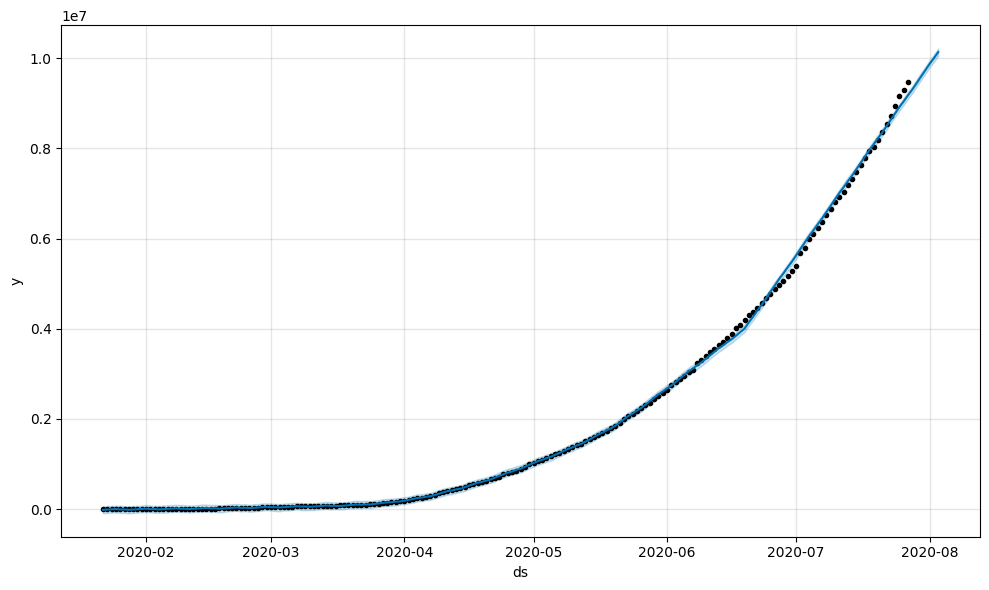

In [ ]:
model.plot(forecast)
plt.show()

Visualization of all 4 cases



INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


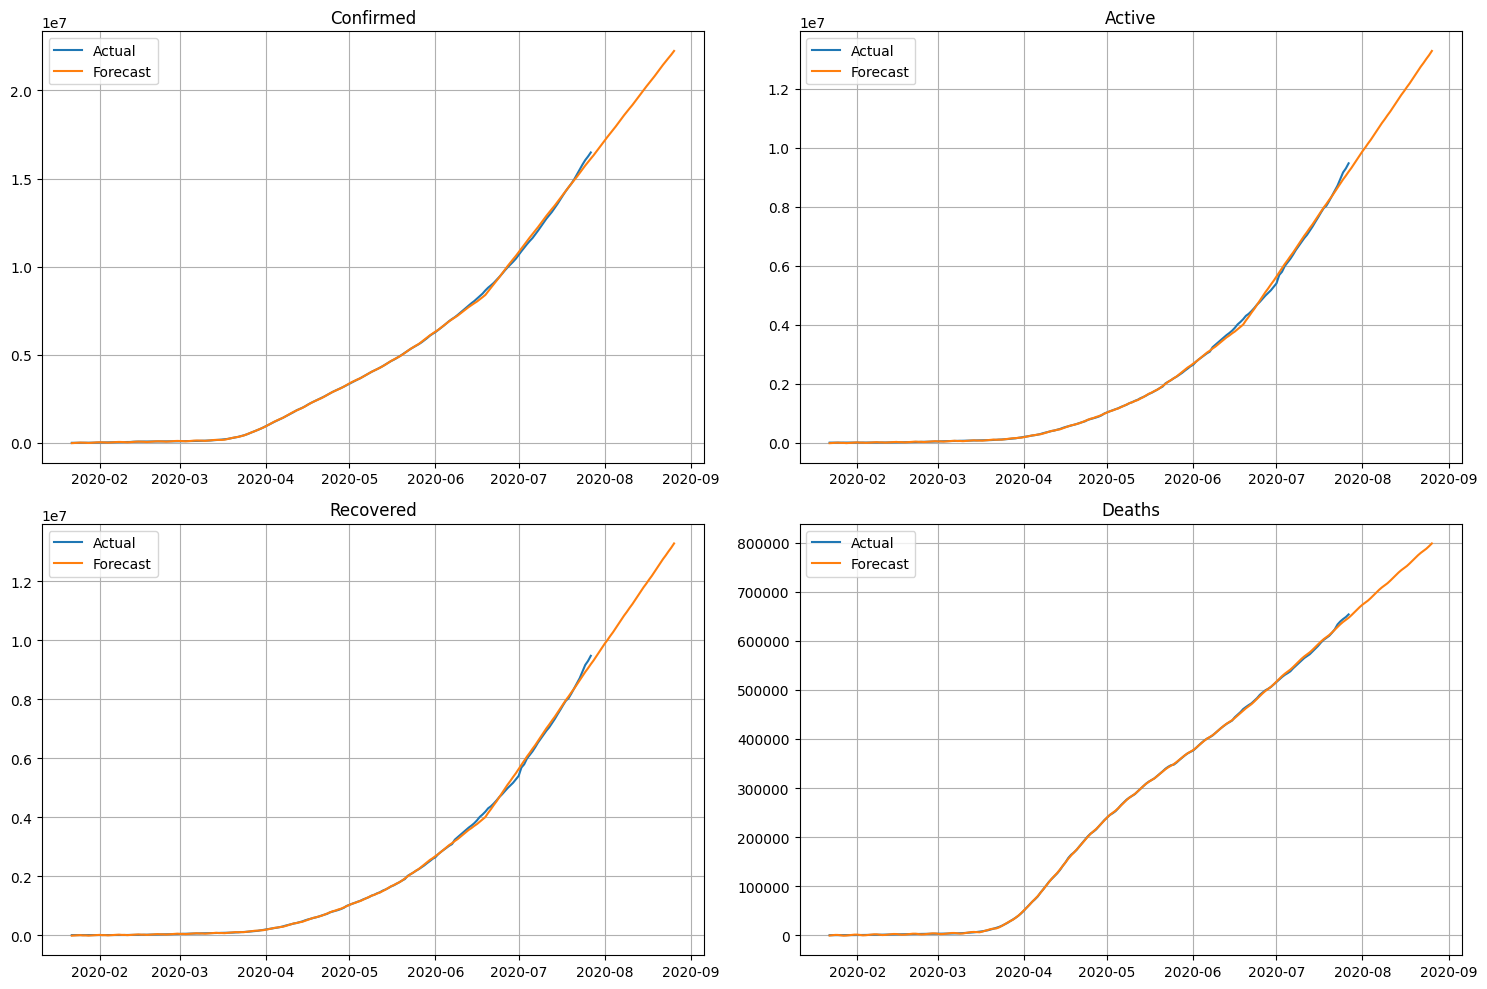

In [ ]:
import matplotlib.pyplot as plt
from prophet import Prophet
import pandas as pd

dfs = [con_prophet_data, act_prophet_data, rec_prophet_data, dea_prophet_data]
titles = ['Confirmed', 'Active', 'Recovered', 'Deaths']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, ax in enumerate(axes.flatten()):
    df_temp = dfs[i].copy()

    # 🔥 Fix datetime
    df_temp['ds'] = pd.to_datetime(df_temp['ds'], errors='coerce')
    df_temp = df_temp.reset_index(drop=True)

    model = Prophet()
    model.fit(df_temp)

    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)

    # 🔥 Fix forecast datetime
    forecast['ds'] = pd.to_datetime(forecast['ds'], errors='coerce')
    forecast = forecast.reset_index(drop=True)

    # plot
    ax.plot(df_temp['ds'], df_temp['y'], label='Actual')
    ax.plot(forecast['ds'], forecast['yhat'], label='Forecast')

    ax.set_title(titles[i])
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

📊 COVID-19 ANALYSIS
– KEY POINTS
Confirmed cases show exponential growth, especially from April to August

Active cases increased continuously, indicating rising pressure on healthcare systems

Recovered cases also grew significantly, showing improvement in treatment and recovery rate

Death cases increased steadily but at a slower pace, indicating a controlled mortality rate

Recovery trend improved after June, suggesting better medical response over time

Forecast data shows a continuous upward trend in all categories

No clear peak observed, meaning the pandemic was still growing during this period

Overall, the data indicates rapid spread with gradual improvement in recovery and control over deaths
